In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import accuracy_score
from scipy.stats import mode

In [4]:
iris = datasets.load_iris()
x=iris.data
y=iris.target
print("shape:",x.shape)

shape: (150, 4)


In [10]:
kmeans = KMeans(n_clusters=3,random_state=0)
kmeans_labels = kmeans.fit_predict(x)
print("K-Means Labels: \n",kmeans_labels)

K-Means Labels: 
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 2 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


In [11]:
gmm = GaussianMixture(n_components=3,random_state=0)
gmm_labels = gmm.fit_predict(x)
print("GMM Labels: \n",gmm_labels)

GMM Labels: 
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 0 2 0
 0 0 0 2 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [14]:
def match_labels(true, pred):
    labels = np.zeros_like(pred)
    for i in range(3):
        mask = (pred == i)
        if np.any(mask):
            labels[mask] = mode(true[mask], keepdims=True).mode[0]
    return labels

In [15]:
kmeans_matched = match_labels(y,kmeans_labels)
gmm_matched = match_labels(y,gmm_labels)

print("K means Accuracy: ",accuracy_score(y,kmeans_matched))
print("GMM Accuracy: ",accuracy_score(y,gmm_matched))

K means Accuracy:  0.8866666666666667
GMM Accuracy:  0.9666666666666667


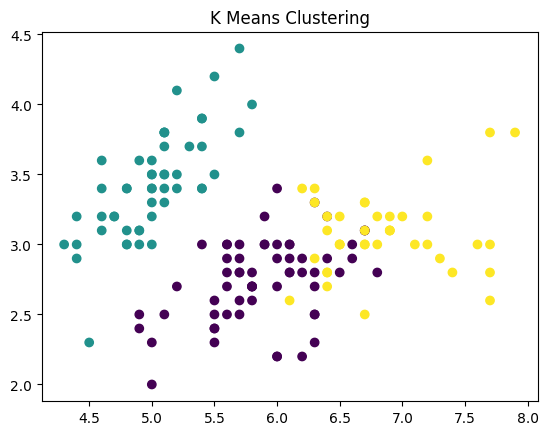

In [17]:
plt.scatter(x[:,0],x[:,1],c=kmeans_labels,cmap="viridis")
plt.title("K Means Clustering")
plt.show()

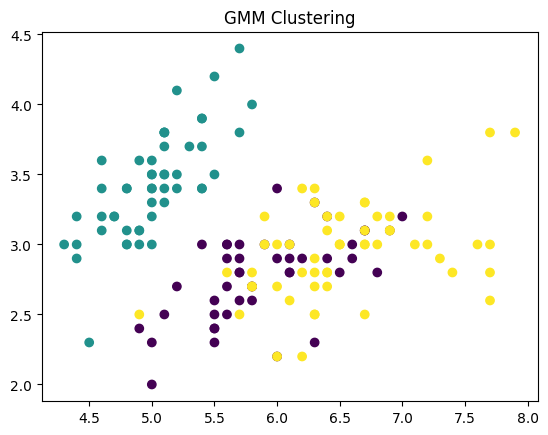

In [18]:
plt.scatter(x[:,0],x[:,1],c=gmm_labels,cmap="viridis")
plt.title("GMM Clustering")
plt.show()